In [5]:
# GraphSAGE regression on a synthetic graph
# Ready-to-run script using NetworkX + PyTorch Geometric

import random
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from torch import nn
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import from_networkx

# -----------------------------
# 1) Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -----------------------------
# 2) Create a synthetic graph
# -----------------------------
num_nodes = 100
feature_dim = 16

# Random geometric graph is simple and gives a realistic local-neighborhood structure
G = nx.random_geometric_graph(num_nodes, radius=0.25, seed=SEED)

# If the graph has isolated nodes or too few edges, add a few random edges for connectivity
if G.number_of_edges() == 0:
    for i in range(num_nodes - 1):
        G.add_edge(i, i + 1)

# -----------------------------
# 3) Create node features and target
# -----------------------------
# Random node features: shape [num_nodes, feature_dim]
x = np.random.randn(num_nodes, feature_dim).astype(np.float32)

# Regression target: simple pattern = sum of first 3 features + small noise
y = x[:, :3].sum(axis=1) + 0.1 * np.random.randn(num_nodes).astype(np.float32)

# Attach features and target to graph nodes so from_networkx can convert them
for i in range(num_nodes):
    G.nodes[i]["x"] = x[i]
    G.nodes[i]["y"] = y[i]

# Convert NetworkX graph to PyG Data object
data = from_networkx(G)
data.x = torch.tensor(np.stack(data.x), dtype=torch.float)
data.y = torch.tensor(np.array(data.y), dtype=torch.float).view(-1, 1)

# -----------------------------
# 4) Train/val/test split with masks
# -----------------------------
node_indices = np.arange(num_nodes)
train_idx, temp_idx = train_test_split(node_indices, test_size=0.36, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=5 / 9, random_state=SEED)
# Resulting proportions: 64% train, 16% val, 20% test

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

# -----------------------------
# 5) Define GraphSAGE model
# -----------------------------
class GraphSAGERegressor(nn.Module):
    def __init__(self, in_channels, hidden_channels=32, out_channels=1):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GraphSAGERegressor(in_channels=feature_dim, hidden_channels=32, out_channels=1).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# -----------------------------
# 6) Helper for evaluation
# -----------------------------
def evaluate(mask):
    model.eval()
    with torch.no_grad():
        pred = model(data.x, data.edge_index)
        loss = criterion(pred[mask], data.y[mask]).item()
        mae = torch.mean(torch.abs(pred[mask] - data.y[mask])).item()
    return loss, mae, pred

# -----------------------------
# 7) Train for ~200 epochs
# -----------------------------
for epoch in range(1, 201):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        val_loss, val_mae, _ = evaluate(data.val_mask)
        print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f}")

# -----------------------------
# 8) Test evaluation
# -----------------------------
test_loss, test_mae, pred = evaluate(data.test_mask)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test MAE:  {test_mae:.4f}")

# -----------------------------
# 9) Show sample predictions
# -----------------------------
test_nodes = torch.where(data.test_mask)[0][:5].cpu().numpy()
print("\nSample predictions vs true values:")
for n in test_nodes:
    p = pred[n].item()
    t = data.y[n].item()
    print(f"Node {n:03d} | Predicted: {p:.4f} | True: {t:.4f}")

# -----------------------------
# 10) Notes for adapting to real data
# -----------------------------
# - Replace the synthetic NetworkX graph with your real graph structure.
# - Make sure each node has a feature vector of the same length.
# - Store node features under a node attribute like "x" before calling from_networkx.
# - Store regression targets under a node attribute like "y".
# - Keep the same mask logic, or substitute your own train/val/test split.

Epoch 020 | Train Loss: 0.2854 | Val Loss: 0.5277 | Val MAE: 0.6263
Epoch 040 | Train Loss: 0.0339 | Val Loss: 0.3018 | Val MAE: 0.4168
Epoch 060 | Train Loss: 0.0034 | Val Loss: 0.3038 | Val MAE: 0.4535
Epoch 080 | Train Loss: 0.0004 | Val Loss: 0.3176 | Val MAE: 0.4599
Epoch 100 | Train Loss: 0.0001 | Val Loss: 0.3080 | Val MAE: 0.4552
Epoch 120 | Train Loss: 0.0000 | Val Loss: 0.3091 | Val MAE: 0.4546
Epoch 140 | Train Loss: 0.0000 | Val Loss: 0.3093 | Val MAE: 0.4546
Epoch 160 | Train Loss: 0.0000 | Val Loss: 0.3098 | Val MAE: 0.4549
Epoch 180 | Train Loss: 0.0000 | Val Loss: 0.3097 | Val MAE: 0.4549
Epoch 200 | Train Loss: 0.0000 | Val Loss: 0.3097 | Val MAE: 0.4549

Test Loss: 0.2932
Test MAE:  0.4413

Sample predictions vs true values:
Node 000 | Predicted: 0.9404 | True: 0.9878
Node 004 | Predicted: 2.1930 | True: 2.0485
Node 005 | Predicted: 0.2129 | True: 1.5200
Node 010 | Predicted: 1.0790 | True: 0.9418
Node 011 | Predicted: 1.3299 | True: 1.0456


/tmp/ipykernel_43580/3971196237.py:55: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data.y = torch.tensor(np.array(data.y), dtype=torch.float).view(-1, 1)


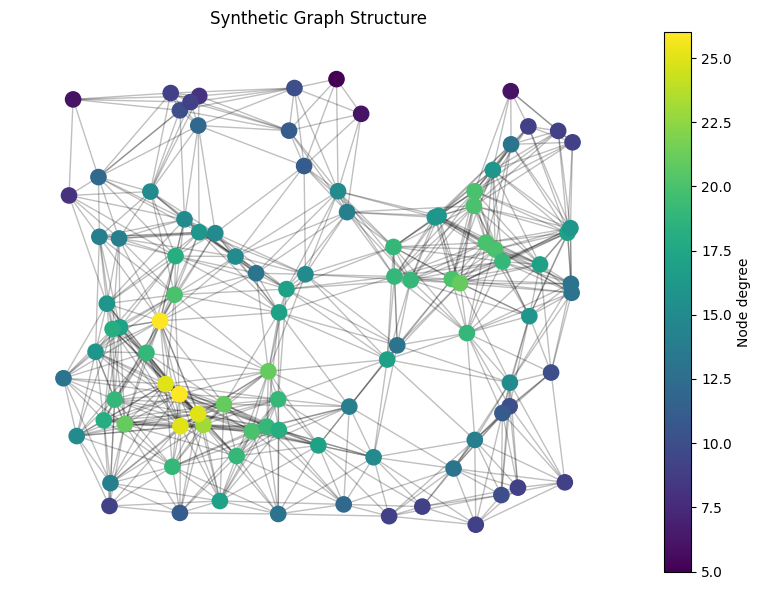

In [7]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(8, 6))
pos = nx.get_node_attributes(G, "pos")
degrees = [G.degree(n) for n in G.nodes()]

nx.draw_networkx_edges(G, pos, alpha=0.25, width=1.0)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=degrees,
    cmap="viridis",
    node_size=120
)

plt.colorbar(nodes, label="Node degree")
plt.title("Synthetic Graph Structure")
plt.axis("off")
plt.tight_layout()
plt.show()